# MVP-1. Принципы быстрого создания MVP

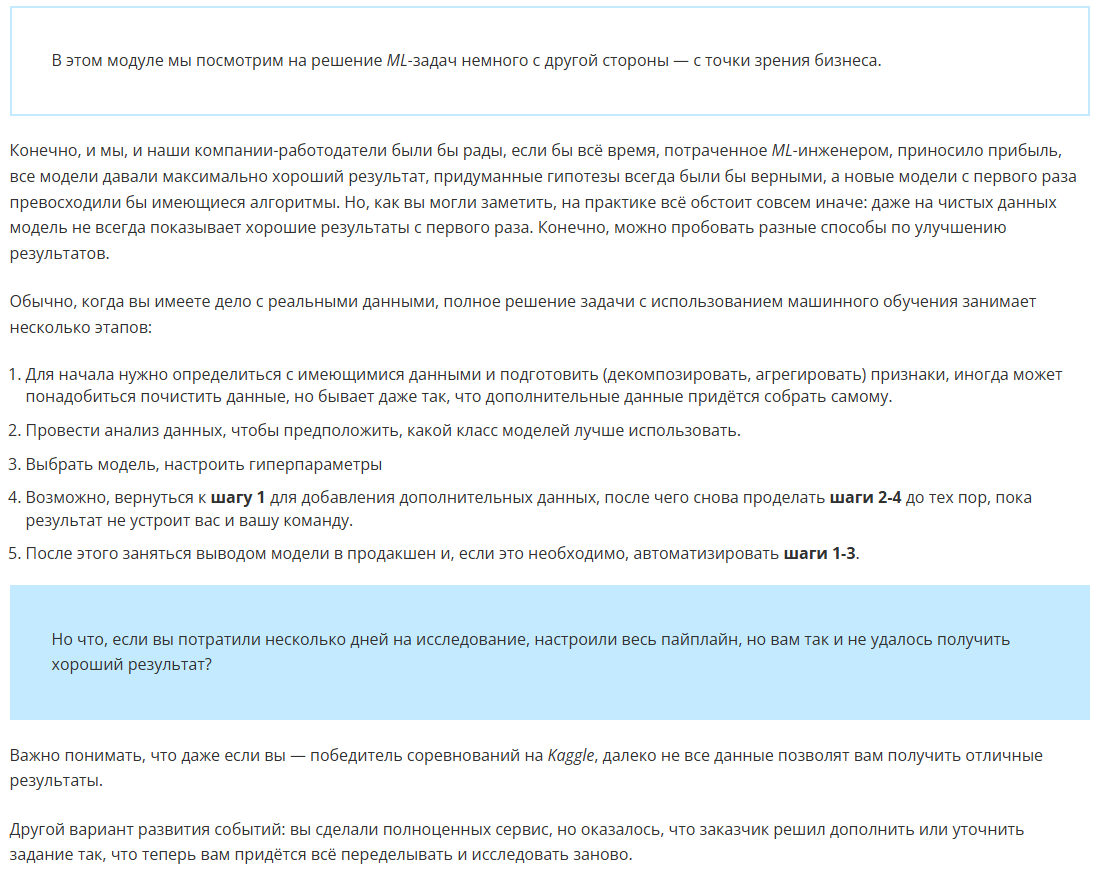

## Что же такое MVP?

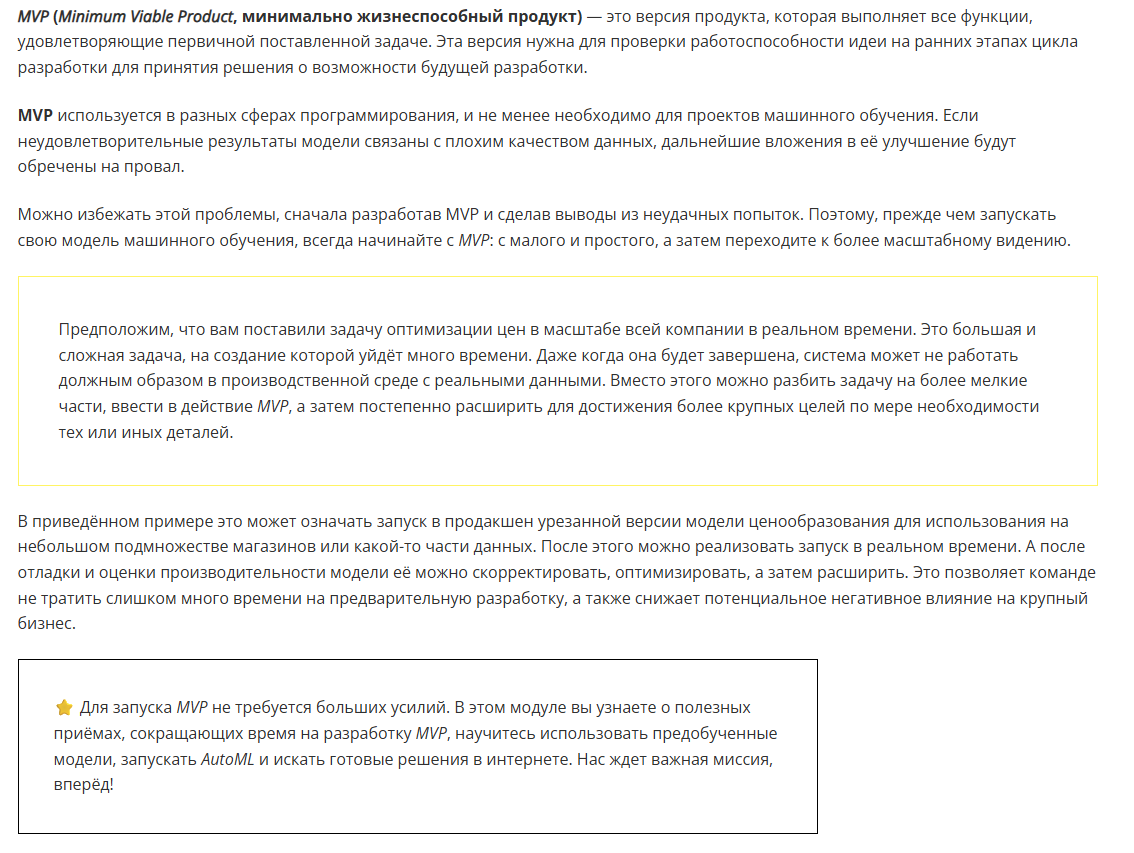

# 2. Предобученные модели

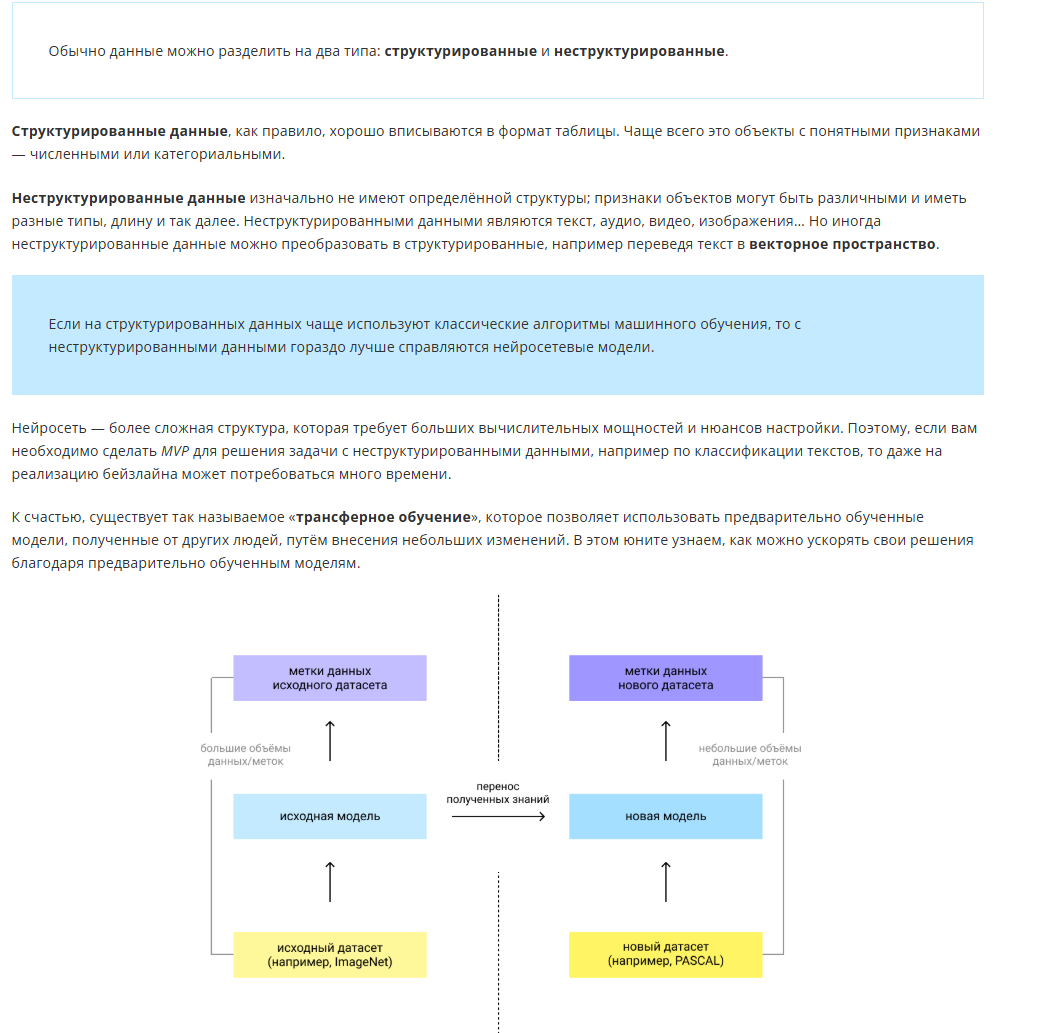

# Что такое предварительно обученная модель? 

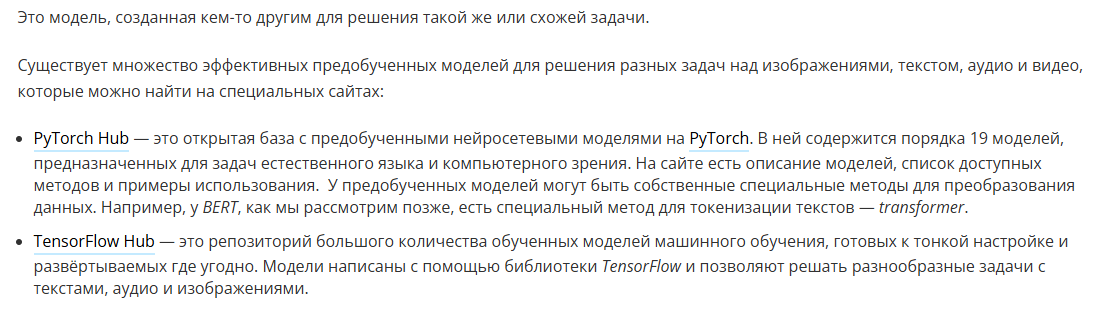

PyTorch Hub https://pytorch.org/hub/

TensorFlow Hub https://www.kaggle.com/models?tfhub-redirect=true

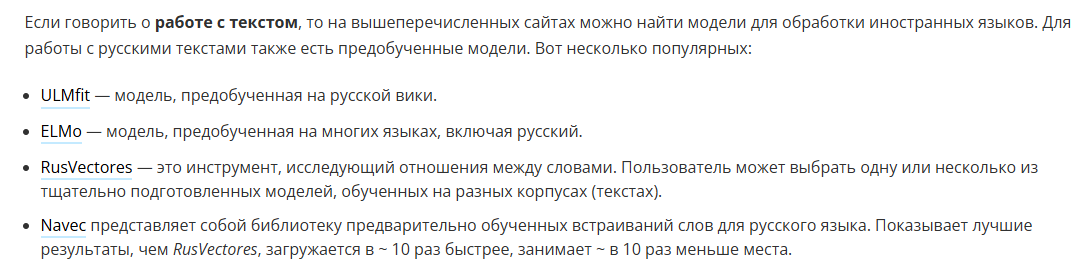

ULMfit https://forums.fast.ai/t/ulmfit-russian/36312

ELMo https://github.com/HIT-SCIR/ELMoForManyLangs

RusVectores https://rusvectores.org/ru/about/

Navec https://github.com/natasha/navec


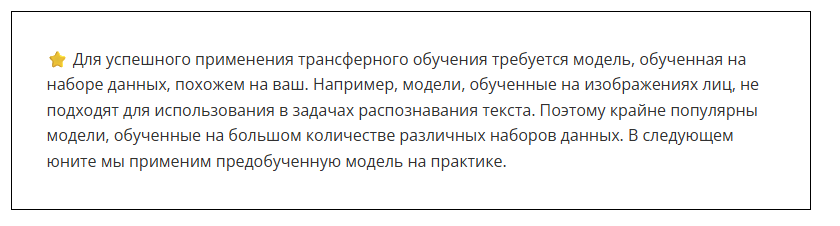

#  3. Предобученные модели. Практика

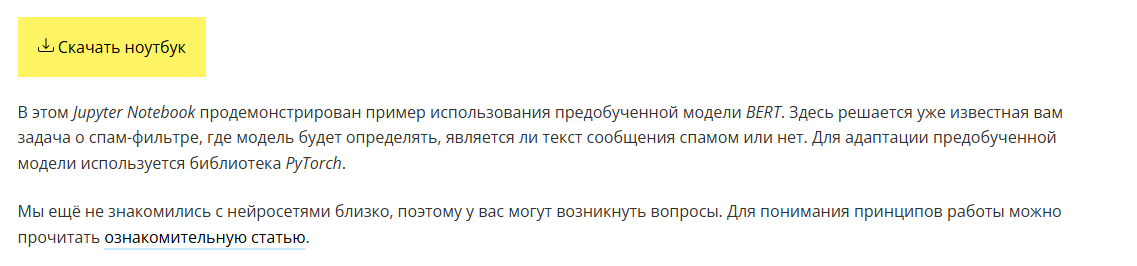

https://habr.com/ru/post/334380/

### Постановка задачи

У нас есть коллекция смс-сообщений. Некоторые из этих сообщений являются спамом, а остальные — нет. Наша задача — построить систему, которая автоматически определяла бы, является ли сообщение спамом. 

⬇️ Набор данных, который мы будем использовать, можно загрузить по ссылке.

Если вы знакомы с Google Colab, то предлагаем вам запускать эту тетрадку там, чтобы вы могли использовать графический процессор для выполнения задачи (для этого активируйте среду выполнения GPU в Colab, щёлкнув Runtime -> Change runtime type -> Select GPU). Также можно запустить тетрадку локально в Jupyter Notebook.

Рекомендуем вам пошагово запустить все этапы и разобраться, как это работает. Так у вас сложится представление о том, как выстраивается пайплайн трансферного обучения.

# 4. Готовые решения для задач ML

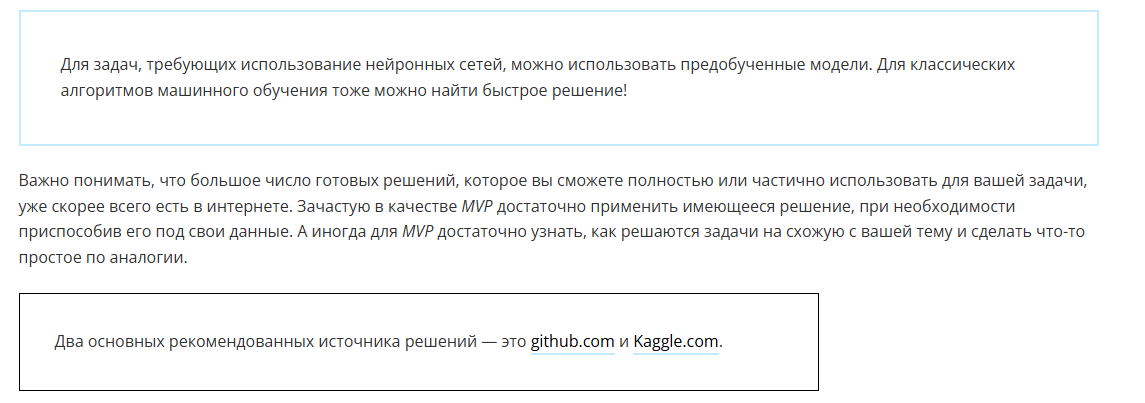

## Поиск решений на GitHub

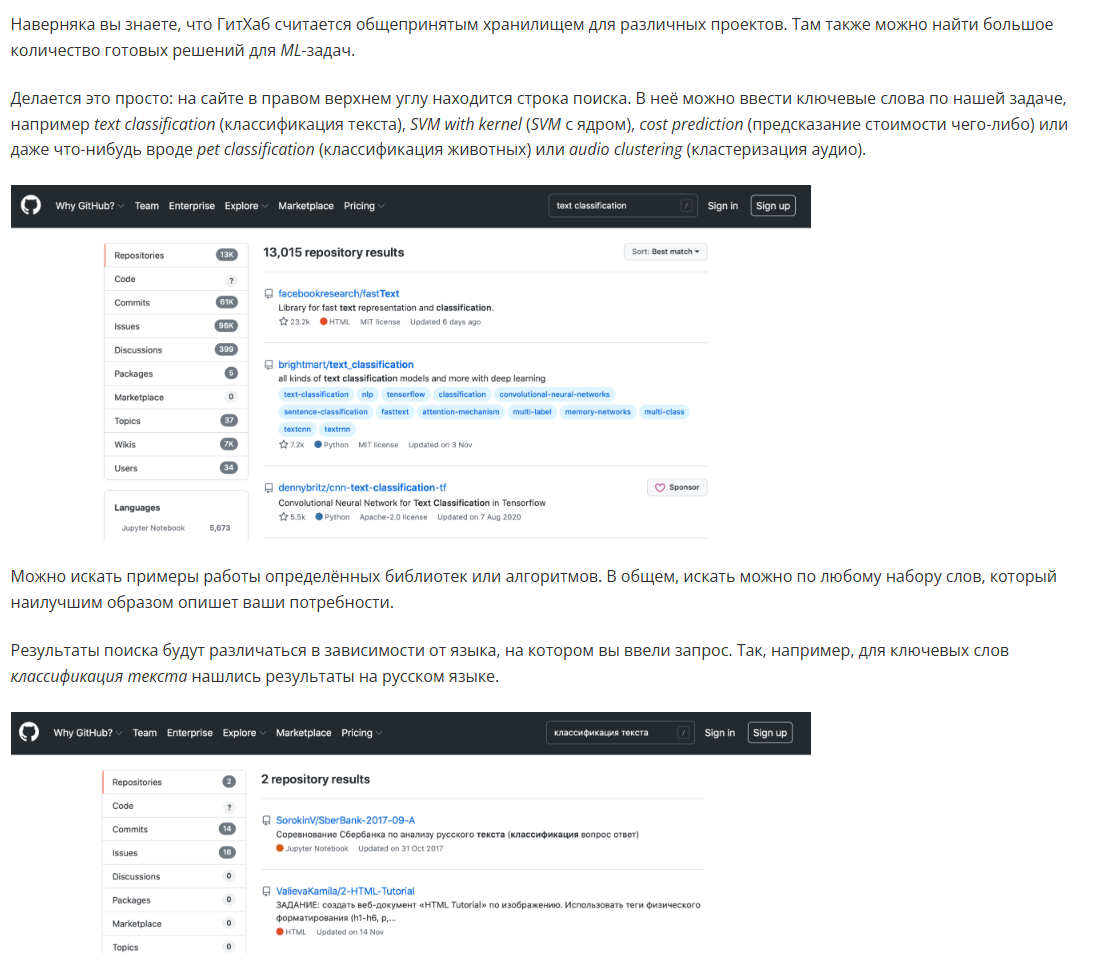

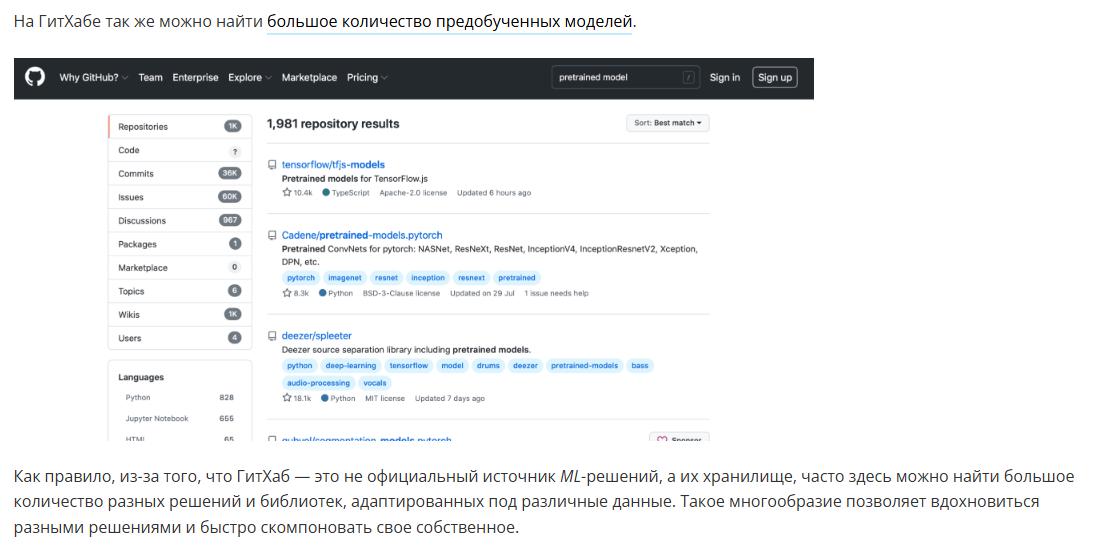

https://github.com/search?q=pretrained+model&type=repositories

## Поиск на Kaggle

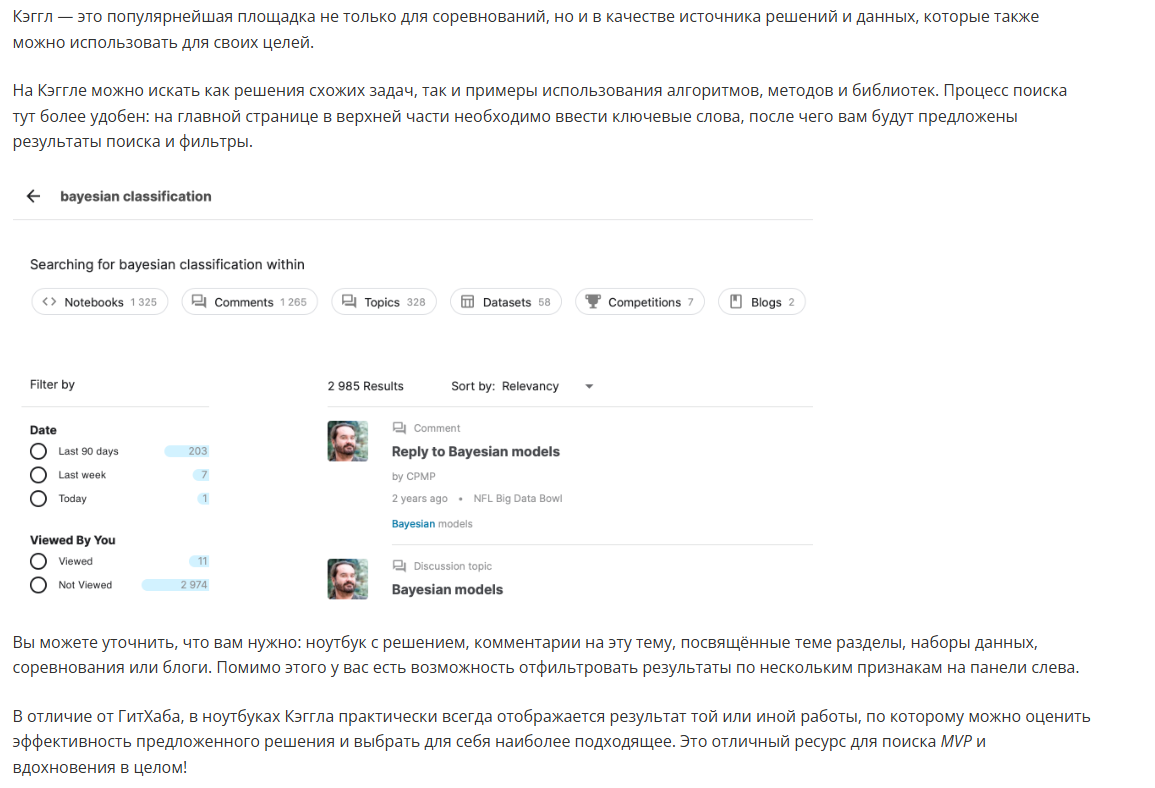

## Поиск в браузере

Конечно, не стоит забывать про поиск в браузере. Помимо выложенных решений вы можете найти различные сайты-агрегаторы готовых решений по темам на разных языках, например:

- Подборка ML-решений по темам на vc.ru https://vc.ru/ai/79368-primenenie-mashinnogo-obucheniya-i-data-science-v-promyshlennosti
- Топ проектов машинного обучения за 2021 год https://data-flair.training/blogs/machine-learning-project-ideas/

Обратите внимание на сайт OpenML https://www.openml.org/home . OpenML — это место, где хранится 21 тысяча интересных наборов данных и около 300 тысяч решений к ним. Там также доступен поиск по ключевым словам и поиск по темам. 

Подобных сайтов достаточно много, поэтому не бойтесь искать решения. Вероятно, вашу задачу или похожую на неё кто-то уже смог решить и не раз! 

# 5. Готовые решения для задач ML. Практика

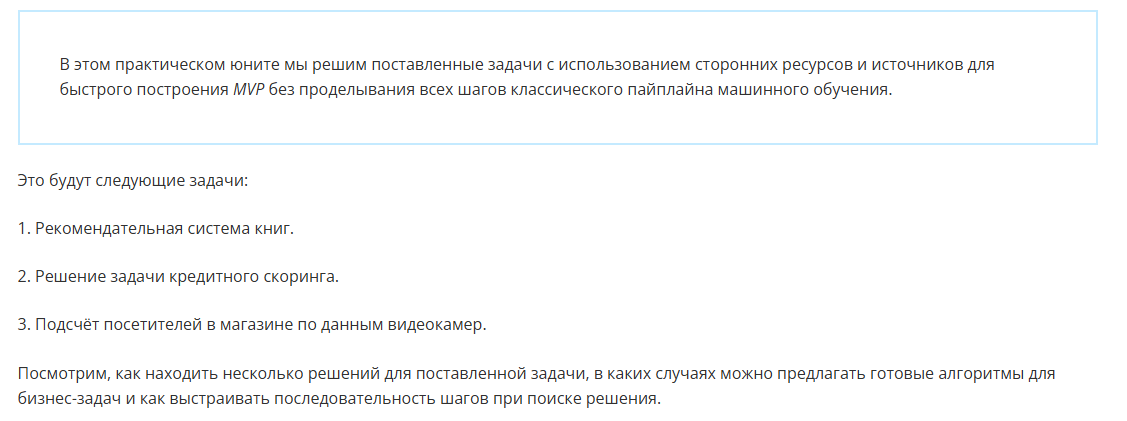

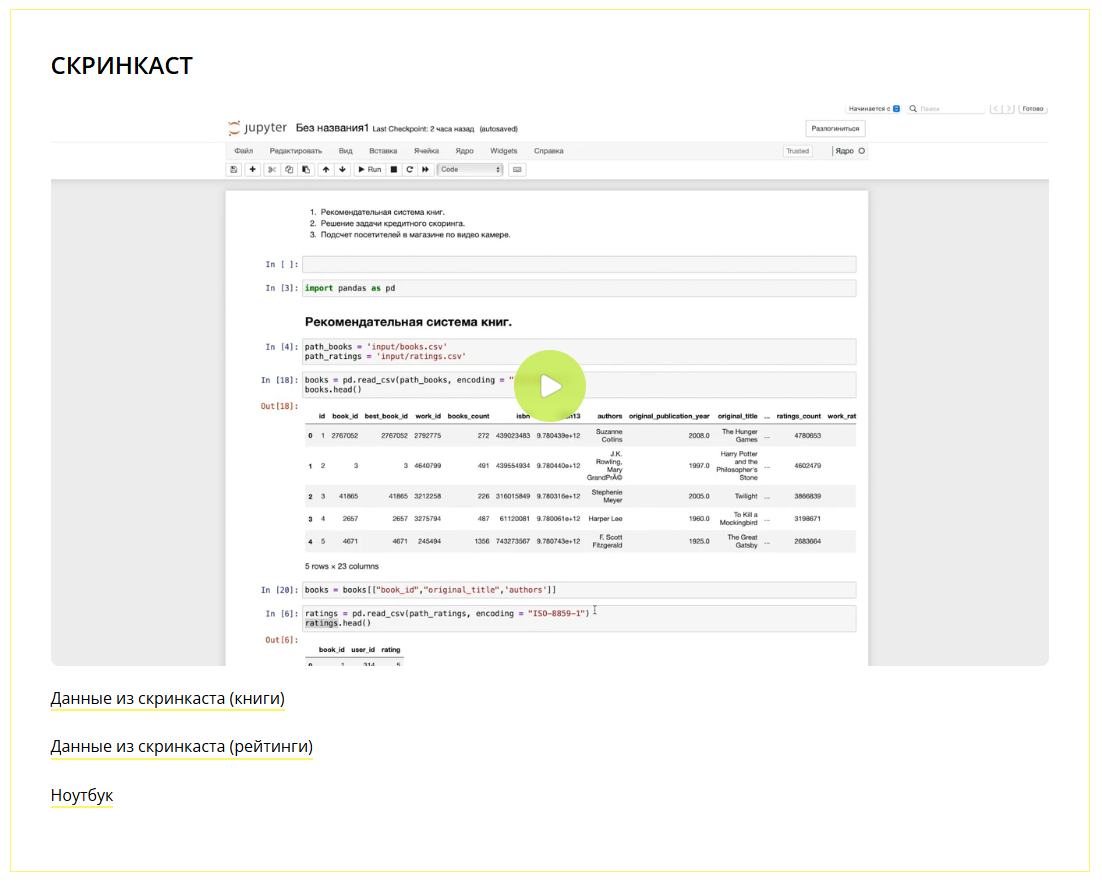

# 6. AutoML

Ещё один инструмент, который позволяет проверить решаемость какой-либо задачи, не тратя при этом много времени — это AutoML. 

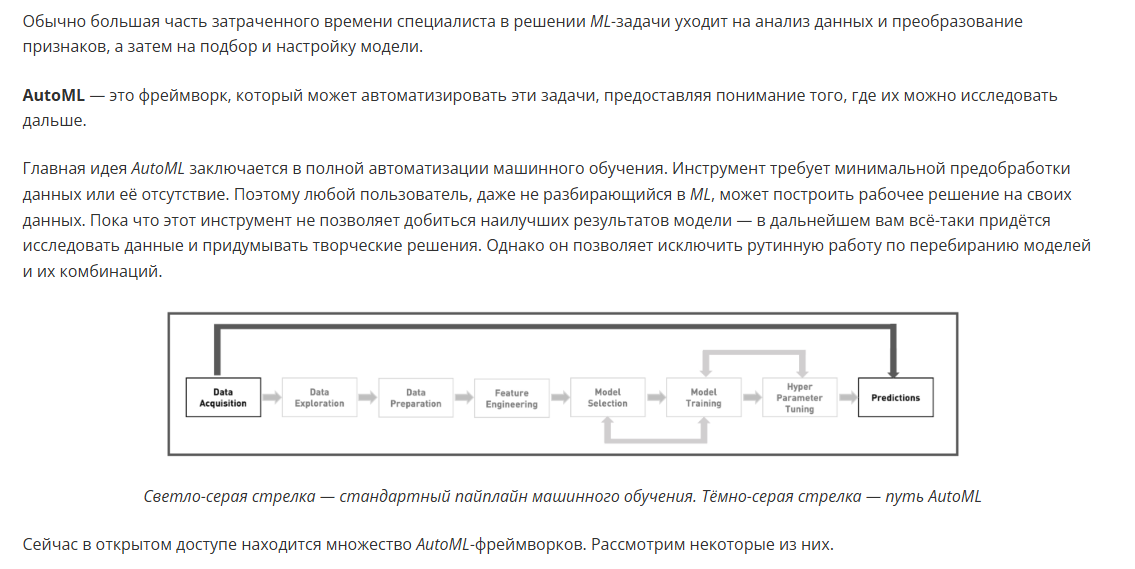

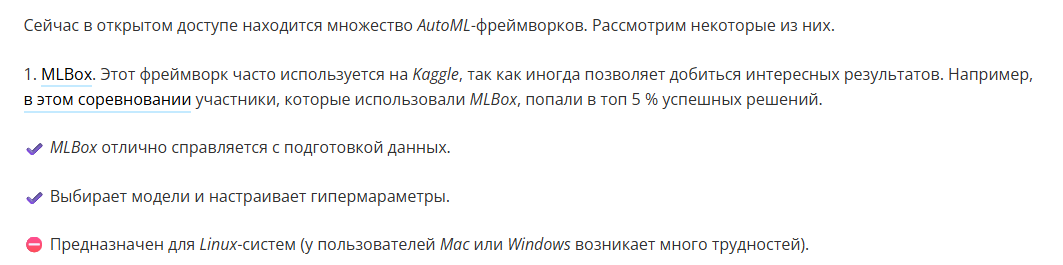

https://mlbox.readthedocs.io/en/latest/

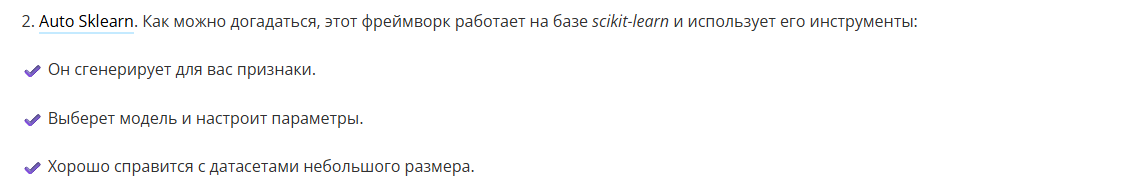

https://automl.github.io/auto-sklearn/master/

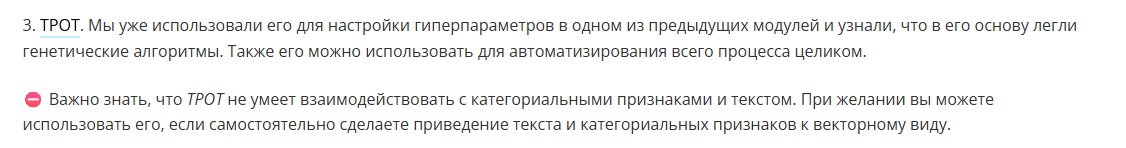

https://epistasislab.github.io/tpot/latest/

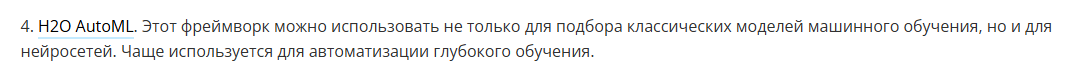

https://docs.h2o.ai/h2o/latest-stable/h2o-docs/automl.html

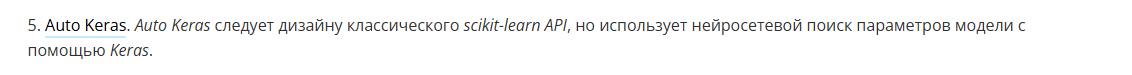

https://autokeras.com/

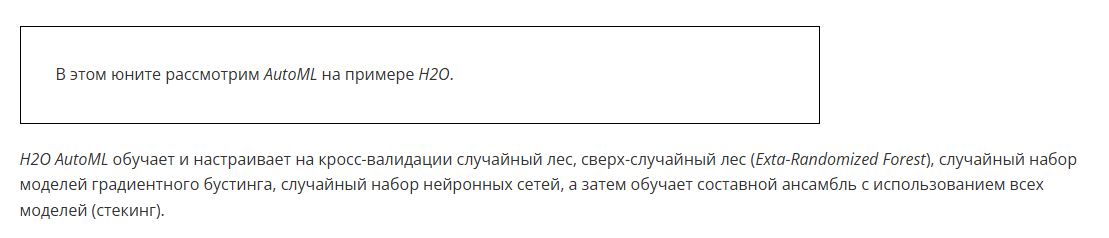

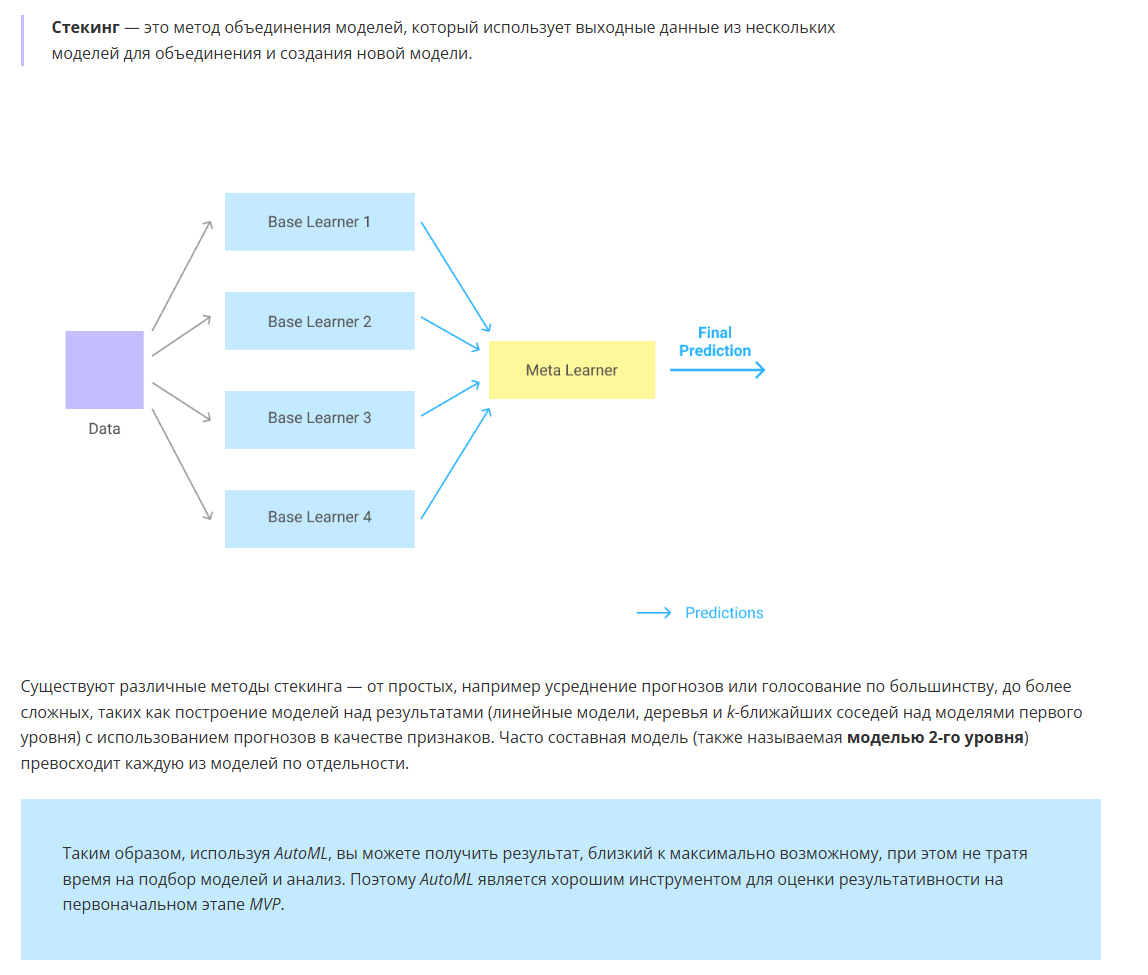

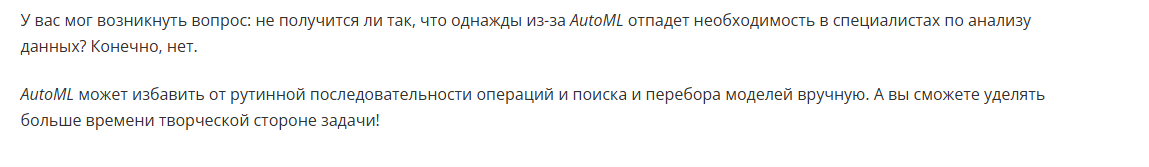

# 7. AutoML. Практика

⬇️ В этом юните мы посмотрим на результат работы AutoML на наборе данных классификации грибов. 

- Набор данных содержит 23 категориальных объекта и более 8 000 наблюдений. 
- Данные делятся на две категории: съедобные и ядовитые. 
- Классы распределены довольно равномерно: 52 % наблюдений приходится на съедобный класс. 
- В данных нет пропущенных наблюдений. 

Сначала вам нужно будет установить и импортировать модуль Python H2O и класс H2OAutoML, как и любую другую библиотеку, и инициализировать H2O.

In [3]:
#pip install h2o

In [10]:
import h2o
from sklearn.preprocessing import LabelEncoder 
from h2o.automl import H2OAutoML

In [11]:
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,31 mins 30 secs
H2O_cluster_timezone:,Asia/Kolkata
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.12
H2O_cluster_version_age:,4 days
H2O_cluster_name:,H2O_from_python_TGorbunov_ju0w2v
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,7.499 Gb
H2O_cluster_total_cores:,20
H2O_cluster_allowed_cores:,20
H2O_cluster_status:,"locked, healthy"



+------------------------------------------------------------------+
| You are running the community edition of H2O-3 OSS.              |
|                                                                  |
| For commercial use, H2O-3 Secure is now recommended.             |
| This includes production support, CVE fixes, multi-node scaling, |
| model artifact extraction, and more.                             |
| See h2o.ai/h2o-3/oss-vs-secure for additional details.           |
| Contact enterprise@h2o.ai to upgrade.                            |
+------------------------------------------------------------------+


Затем нам нужно загрузить данные. Это можно сделать либо прямо в «H2OFrame» (закомментированный пример), либо обычным способом, чтобы мы могли закодировать целевую переменную, а затем преобразовать их в H2OFrame. 

Как и многие функции и объекты в H2O, H2OFrame схож с Pandas DataFrame, но имеет свои небольшие отличия и синтаксис. Например, H2O может самостоятельно обрабатывать категориальные признаки, поэтому выполнять этот шаг отдельно не требуется.

In [12]:
import pandas as pd

df = pd.read_csv("data_mvp1/mushrooms.csv")
# df = h2o.import_file("mushrooms.csv", header =1)

labelEncoder = LabelEncoder()
for column in df.columns:
    df[column] = labelEncoder.fit_transform(df[column])
df = h2o.H2OFrame(df)
df = df.asfactor()

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


На этом этапе при создании MVP есть два пути:

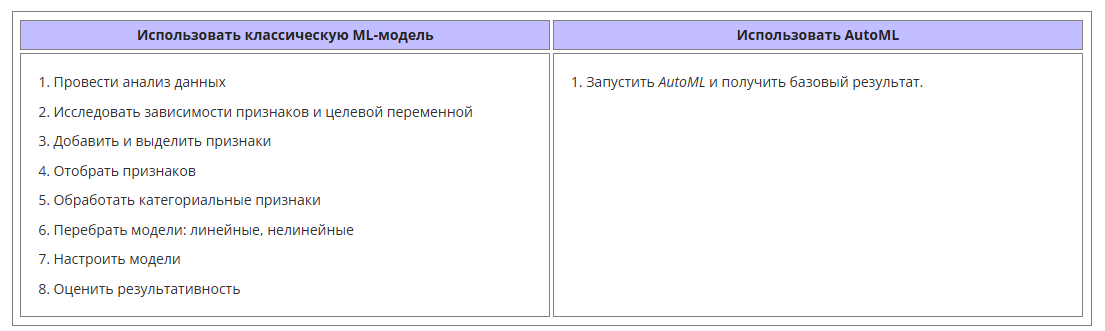

Получается, с использованием AutoML мы не будем проделывать эти шаги и сразу перейдём к обучению!

Подобно функциям в sklearn, мы можем создать разбиение на train и test, чтобы можно было проверить производительность модели на неизвестном наборе данных. 

In [13]:
# Разделяем данные на Train/Test/Validation. Train размером 70%, test и validation по 15% 
train_df, test_df = df.split_frame(ratios=[.7])

Затем нам нужно получить имена столбцов, чтобы передать их функции. 

Для AutoML необходимо указать несколько обязательных параметров: **x**, **y** и **training_frame**. Здесь вы также можете настроить значения max_runtime_sec и max_models. 

- Max_runtime_sec — **обязательный параметр**, а max_model — необязательный. 
- По умолчанию все непереданные параметры принимают значение NULL. 
- Параметр x — это вектор признаков из training_frame. Если вы не хотите использовать все признаки из переданного кадра, вы можете установить его, передав его в x.

На этих данных будем использовать все признаки (кроме таргета) и установим max_runtime_sec на 10 минут (по умолчанию некоторые из моделей могут занять много времени). Запустим AutoML:

In [14]:
y = "class"
train_columns = train_df.columns
train_columns.remove(y)

aml_model = H2OAutoML(max_runtime_secs=500, seed = 1)
aml_model.train(x = train_columns, y = y, training_frame = train_df)

AutoML progress: |
19:27:20.694: AutoML: XGBoost is not available; skipping it.
19:27:20.697: _train param, Dropping bad and constant columns: [veil-type]


19:27:21.749: _train param, Dropping bad and constant columns: [veil-type]

█████
19:27:37.674: _train param, Dropping unused columns: [veil-type]


19:27:39.424: _train param, Dropping bad and constant columns: [veil-type]
19:27:40.178: _train param, Dropping bad and constant columns: [veil-type]

███
19:27:52.853: _train param, Dropping bad and constant columns: [veil-type]

██
19:28:06.378: _train param, Dropping bad and constant columns: [veil-type]

█
19:28:21.210: _train param, Dropping unused columns: [veil-type]
19:28:22.591: _train param, Dropping unused columns: [veil-type]

█
19:28:24.301: _train param, Dropping bad and constant columns: [veil-type]


19:28:25.447: _train param, Dropping bad and constant columns: [veil-type]

████
19:28:36.55: _train param, Dropping bad and constant columns: [veil-type]


19:28:36.962: _

key,value
Stacking strategy,cross_validation
Number of base models (used / total),25/45
# GBM base models (used / total),22/24
# DeepLearning base models (used / total),3/18
# GLM base models (used / total),0/1
# DRF base models (used / total),0/2
Metalearner algorithm,GLM
Metalearner fold assignment scheme,Random
Metalearner nfolds,5
Metalearner fold_column,None


Мы задали значение параметра Max_runtime_sec ~10 минут, но также есть параметр, отвечающий не за время, а за **максимальное количество исследованных моделей**. Помимо этого, есть возможности дополнительной настройки процесса работы AutoML и множество дополнительных параметров, которые вы можете задать. 

Подробнее о параметрах можно прочитать в официальной документации. https://docs.h2o.ai/h2o/latest-stable/h2o-docs/automl.html

После запуска и обучения H2OAutoML вы можете посмотреть, какие модели в нашем случае сработали лучше всего, и выбрать их для дальнейшего исследования.

In [15]:
leaderboard = aml_model.leaderboard
leaderboard.head()

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse
StackedEnsemble_AllModels_4_AutoML_2_20260815_192720,1,0.000631339,1,0,0.000631697,3.99041e-07
GBM_grid_1_AutoML_2_20260815_192720_model_17,1,1.74485e-08,1,0,1.31872e-06,1.73903e-12
GBM_grid_1_AutoML_2_20260815_192720_model_3,1,1.21586e-09,1,0,8.31391e-08,6.91211e-15
GBM_1_AutoML_2_20260815_192720,1,6.48477e-13,1,0,3.33085e-11,1.10946e-21
DeepLearning_grid_1_AutoML_2_20260815_192720_model_3,1,0.000427234,1,0,0.0107644,0.000115872
StackedEnsemble_BestOfFamily_6_AutoML_2_20260815_192720,1,0.00303398,1,0,0.00356887,1.27368e-05
StackedEnsemble_AllModels_2_AutoML_2_20260815_192720,1,0.000667416,1,0,0.00066784,4.4601e-07
GBM_5_AutoML_2_20260815_192720,1,7.69708e-12,1,0,5.81575e-10,3.3823e-19
StackedEnsemble_AllModels_5_AutoML_2_20260815_192720,1,0.003264,1,0,0.00328239,1.07741e-05
GBM_grid_1_AutoML_2_20260815_192720_model_4,1,4.96326e-17,1,0,1.36613e-15,1.86632e-30


Давайте проверим результат предсказания на тестовых данных и посмотрим, не переобучилась ли модель:

In [16]:
prediction = aml_model.predict(test_df)

stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%


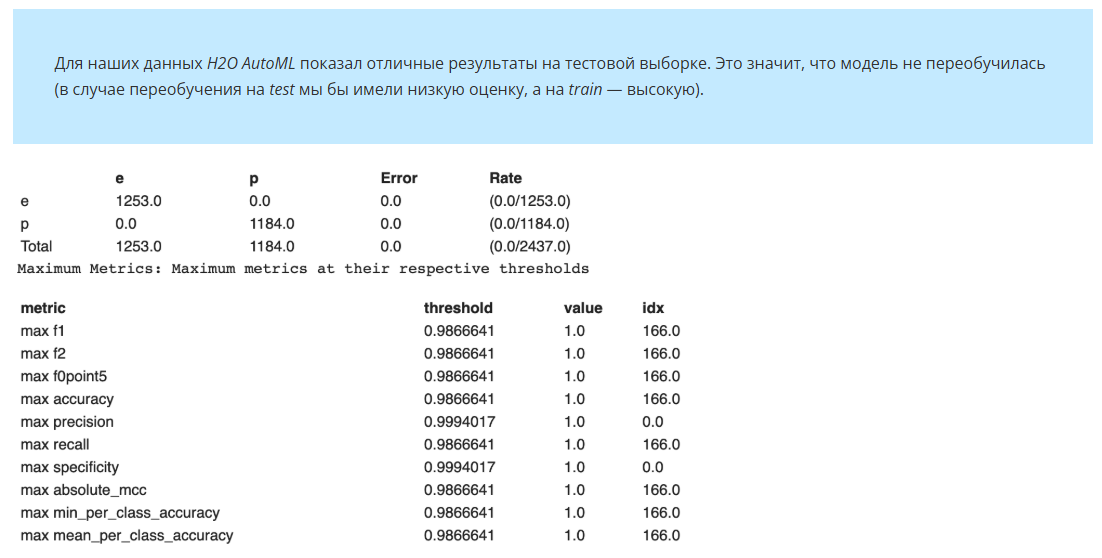

Получив лучшую (из исследуемых) модель, можно выполнить несколько шагов, которые могут повысить производительность модели (на следующем этапе после MVP):

- Подготовка признаков (feature engineering).
- Добавление новых признаков с учётом имеющихся зависимостей и выявление новых (feature extraction).
- Отбор наиболее важных признаков для модели (feature selection). 
- Многие из лучших моделей в H2O AutoML используют ансамблирование. Эти модели можно дополнительно настроить.

✔️ Несмотря на то, что AutoML не принесёт вам призовых мест в соревнованиях по машинному обучению на Kaggle или лучших результатов для рабочих задач, его определённо стоит рассмотреть в качестве дополнения к вашим простым моделям и бейзлайну.

✔️  AutoML может обрабатывать множество различных типов наборов данных, включая бинарную классификацию (как мы посмотрели выше), многоклассовую классификацию, а также задачи регрессии.

✔️  AutoML — отличный инструмент, помогающий в работе (а не заменяющий её). Но когда дело доходит до feature engineering, такой автоматизированный инструмент не может превзойти творческое мышление человека. 

# 8. Подведём итоги

Теперь вы знаете, что главной целью MVP является первичная оценка реализуемости и эффекта, а не качества. Кроме того, вы выяснили, почему не стоить тратить много времени на его реализацию.

Не бойтесь гуглить! Существует большое множество различных источников готовых решений практически под любой запрос.

Умение быстро использовать уже реализованные решения машинного обучения из интернета, а главное — уметь разобраться в чужом коде и применить его. Это очень ценный навык, который поможет сэкономить много вашего времени и средств компании. 

В дополнительных материалах мы собрали для вас полезные ссылки по готовым решениям.

Дополнительные материалы

Статьи со ссылками на GitHub-репозитории в области машинного обучения

- Крутые GitHub репозитории в области машинного обучения https://habr.com/ru/articles/584048/
- Другой Github 2: машинное обучение, датасеты и Jupyter Notebooks https://habr.com/ru/companies/vk/articles/445530/
- 30 самых удивительных проектов по машинному обучению https://rb.ru/stories/30-ml-projects/

Дополнительные источники с предобученными моделями

- Model Zoo (GitHub) https://modelzoo.co/
- facebookarchive https://github.com/facebookarchive/models
- github.com/BVLC/caffe/wiki/Model-Zoo https://github.com/BVLC/caffe/wiki/Model-Zoo
- Keras Applications https://keras.io/api/applications/
- Torchvision Models https://docs.pytorch.org/vision/0.8/models.html
- TensorFlow Models https://github.com/tensorflow/models